In [ ]:
import pandas as pd

# load data
df = pd.read_csv('diabetes.csv')

In [ ]:
# rename label column
df = df.rename(columns={'label': 'is_diabetes'})

In [ ]:
print(df.shape)
df.head()

(768, 9)


,pr,glucose,bp_diastolic,skin_triceps,insulin,bmi,pedigree,age,is_diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**PART (a): Simple Linear Regression (Manual - linregress)**

glucose = independent (X)

is_diabetes = dependent (y)

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import linregress

# variables
x1 = df['glucose']
y1 = df['is_diabetes']

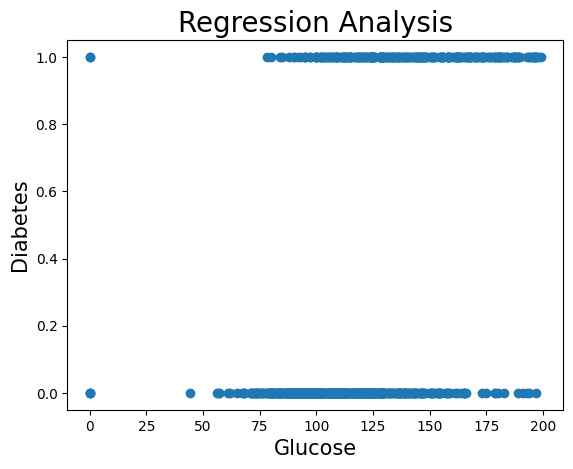

In [ ]:
# scatter plot
plt.scatter(x1, y1)
plt.title("Regression Analysis", fontsize=20)
plt.xlabel("Glucose", fontsize=15)
plt.ylabel("Diabetes", fontsize=15)
plt.show()

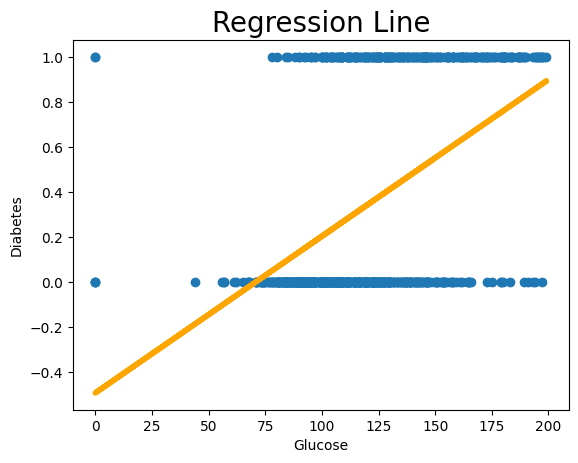

In [ ]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x1, y1)

# regression line
y2 = slope * x1 + intercept

# plot line
plt.scatter(x1, y1)
plt.plot(x1, y2, lw=4, c='orange')
plt.title("Regression Line", fontsize=20)
plt.xlabel("Glucose")
plt.ylabel("Diabetes")
plt.show()

In [ ]:
# prediction example
given_glucose = 150
pred_diabetes = slope * given_glucose + intercept
print("Predicted value:", pred_diabetes)

Predicted value: 0.551538966449006


*Actual vs Predicted*

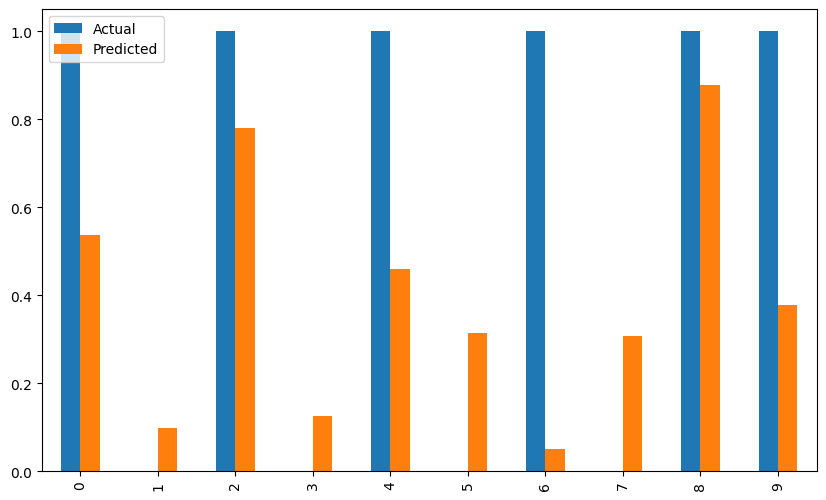

In [ ]:
df_p = pd.DataFrame({
    "Actual": y1,
    "Predicted": y2
})

df_p.head()

df_p.head(10).plot(kind="bar", figsize=(10,6))
plt.show()

*Seaborn Regression Plot*

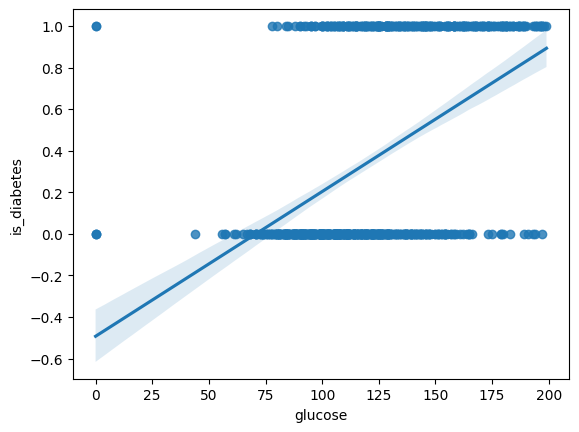

In [ ]:
import seaborn as sns

sns.regplot(data=df, x='glucose', y='is_diabetes')
plt.show()

**PART (b): Train/Test + Sklearn Linear Regression**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df['glucose']
y = df['is_diabetes']

In [ ]:
# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

# reshape
X_train = X_train.to_numpy().reshape(-1,1)
X_test = X_test.to_numpy().reshape(-1,1)


In [ ]:
# model
model = LinearRegression()
model.fit(X_train, y_train)

# prediction
y_pred = model.predict(X_test)

# compare
result = pd.DataFrame({
    "Original": y_test,
    "Predicted": y_pred
})

In [ ]:
result.head()

,Original,Predicted
285,0,0.443387
101,0,0.546004
581,0,0.258675
352,0,-0.069700
726,0,0.306564


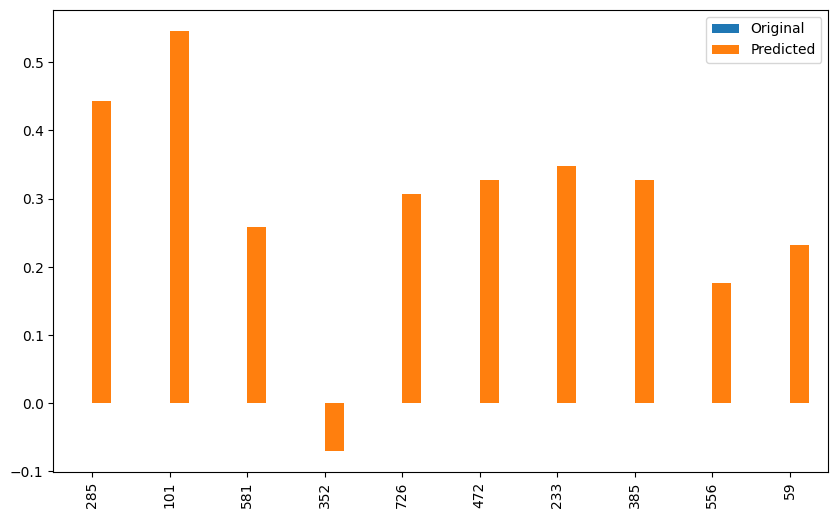

In [ ]:
result.head(10).plot(kind="bar", figsize=(10,6))
plt.show()

*Evaluation Metrics*

In [ ]:
from sklearn import metrics
import numpy as np

print("Evaluation indicators")
print("MAE:\t", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:\t", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:\t", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R-Squared:", metrics.r2_score(y_test, y_pred))

Evaluation indicators
MAE:	 0.34807541976313133
MSE:	 0.17497670634284895
RMSE:	 0.4183021710950697
R-Squared: 0.24762836203378247


**PART (c): Gradient Descent (Manual)**

In [ ]:
import numpy as np

# initialize
b0 = 0.0
b1 = 0.0
learning_rate = 0.00001
epochs = 1000

n = float(len(X_train))

x_vals = X_train.flatten()
y_vals = y_train.to_numpy()

In [ ]:
# gradient descent loop
for i in range(epochs):
    y_current = b1 * x_vals + b0

    D_b1 = (-2/n) * sum(x_vals * (y_vals - y_current))
    D_b0 = (-2/n) * sum(y_vals - y_current)

    b1 = b1 - learning_rate * D_b1
    b0 = b0 - learning_rate * D_b0

print("Intercept (b0):", b0)
print("Slope (b1):", b1)

Intercept (b0): -0.0005836193755708517
Slope (b1): 0.003071986747280259


*Predictions + Evaluation*

In [ ]:
y_pred_gd = b1 * X_test.flatten() + b0

print("--- Gradient Descent Evaluation ---")
print("MAE:\t", metrics.mean_absolute_error(y_test, y_pred_gd))
print("MSE:\t", metrics.mean_squared_error(y_test, y_pred_gd))
print("RMSE:\t", np.sqrt(metrics.mean_squared_error(y_test, y_pred_gd)))
print("R-Squared:", metrics.r2_score(y_test, y_pred_gd))

--- Gradient Descent Evaluation ---
MAE:	 0.4156996688097247
MSE:	 0.19324439274359867
RMSE:	 0.4395957151105987
R-Squared: 0.16908025453737585


*Visualization*

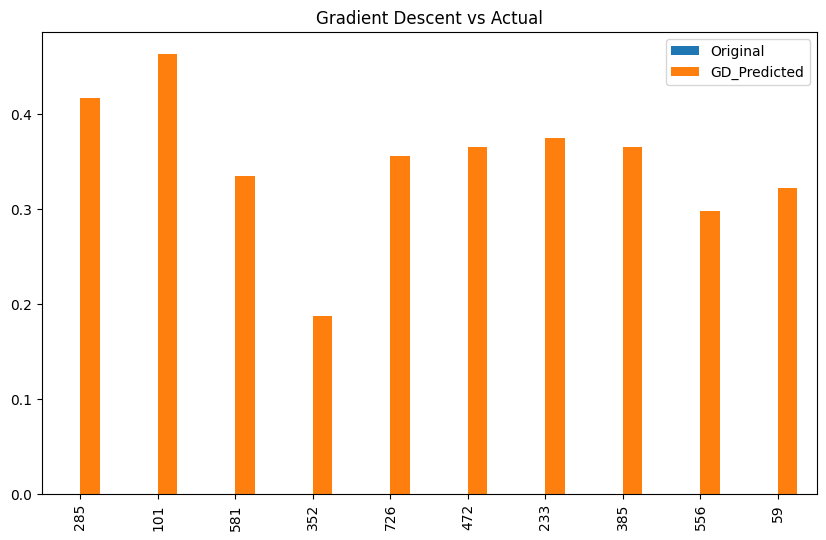

In [ ]:
y_compare = pd.DataFrame({
    "Original": y_test,
    "GD_Predicted": y_pred_gd
})

y_compare.head(10).plot(kind="bar", figsize=(10,6),
                       title="Gradient Descent vs Actual")
plt.show()